# Homework 06 - Trees
The goal of this homework is to predict the fuel efficiency of a car using a decision tree regression model.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import export_text
from matplotlib import pyplot as plt
%matplotlib inline

## Dataset
This homework will be using the fuel efficiency dataset.

In [2]:
fe_url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
fe_df = pd.read_csv(fe_url)
fe_df.columns = fe_df.columns.str.lower().str.replace(' ', '_')
fe_df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


## Data preparation
Replace any missing values with `0.0`.
Split the data into train/val/test (60%/20%/20%).

In [3]:
fe_df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [4]:
fe_df = fe_df.fillna(0.0)

In [5]:
fe_df.isna().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [6]:
full_train_df, test_df = train_test_split(fe_df, test_size=0.2, random_state=1)
train_df, val_df = train_test_split(full_train_df, test_size=0.25, random_state=1)
(len(train_df), len(val_df), len(test_df))

(5822, 1941, 1941)

## Question 1
With a `max_depth=1`, what feature is used for splitting the data?

In [7]:
def train_dtree(tr_df, depth):
    train_dict = tr_df.drop('fuel_efficiency_mpg', axis=1).to_dict(orient='records')
    train_y = tr_df.fuel_efficiency_mpg.values

    
    dv = DictVectorizer(sparse=False)
    train_X = dv.fit_transform(train_dict)
    
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(train_X, train_y)

    return dt, dv

In [8]:
train_df.fuel_efficiency_mpg.values

array([15.3014754 , 15.33121466, 15.33667895, ..., 15.18828665,
       17.3967514 , 16.16090373], shape=(5822,))

In [9]:
dtree, dvect = train_dtree(train_df, 1)
print(export_text(dtree, feature_names=list(dvect.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## Question 2
After training a random forest regressor, what is the RMSE on the validation data?

In [10]:
def rmse(y, y_pred):
    err = y_pred - y
    sqrd_err = err ** 2
    mean_sqrd_err = sqrd_err.mean()
    return np.sqrt(mean_sqrd_err)

In [11]:
def prep_frames(tr_df, v_df):
    train_dict = tr_df.drop('fuel_efficiency_mpg', axis=1).to_dict(orient='records')
    train_y = tr_df.fuel_efficiency_mpg.values

    val_dict = v_df.drop('fuel_efficiency_mpg', axis=1).to_dict(orient='records')
    val_y = v_df.fuel_efficiency_mpg.values
    
    dv = DictVectorizer(sparse=False)
    train_X = dv.fit_transform(train_dict)
    val_X = dv.transform(val_dict)

    return train_X, train_y, val_X, val_y, dv
    
def train_val_rforest(t_X, t_y, v_X, v_y, n_e=10, m_d=None):
    rf = RandomForestRegressor(n_estimators=n_e, max_depth=m_d, random_state=1)
    rf.fit(t_X, t_y)

    pred_y = rf.predict(v_X)

    return rmse(v_y, pred_y)

def train_and_test_rforest(t_df, v_df, n_e=10, m_d=None):
    train_X, train_y, val_X, val_y, dv = prep_frames(t_df, v_df)
    return train_val_rforest(
        train_X,
        train_y,
        val_X,
        val_y,
        n_e,
        m_d
    )

In [12]:
round(float(train_and_test_rforest(train_df, val_df)), 3)

0.46

## Question 3
After which value of `n_estimators` does RMSE stop improving?

In [13]:
n_e_rmse = []

t_X, t_y, v_X, v_y, dv = prep_frames(train_df, val_df)

for n_estimator in range(10, 201, 10):
    curr_rmse = round(
        float(
            train_val_rforest(
                t_X,
                t_y,
                v_X,
                v_y,
                n_estimator
            )
        ),
        3
    )
    n_e_rmse.append((n_estimator, curr_rmse))

ner_df = pd.DataFrame(n_e_rmse, columns=['n_estimator', 'rmse'])

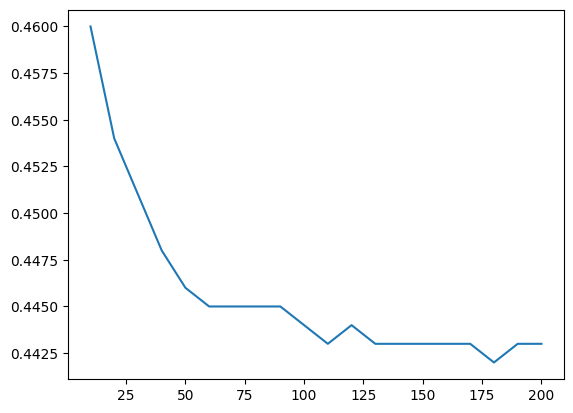

In [14]:
plt.plot(ner_df.n_estimator, ner_df.rmse)

## Question 4
What's the best `max_depth`, using the mean RMSE?

In [15]:
md_mrmse = []

for max_depth in [10, 15, 20, 25]:
    n_e_rmses = []
    for n_estimator in range(10, 201, 10):
        n_e_rmses.append(
            round(
                float(
                    train_val_rforest(
                        t_X,
                        t_y,
                        v_X,
                        v_y,
                        n_estimator,
                        max_depth
                    )
                ),
                3
            )
        )
    md_mrmse.append((max_depth, np.mean(n_e_rmses)))

pd.DataFrame(md_mrmse, columns=['max_depth', 'mean_rmse'])

,max_depth,mean_rmse
0,10,0.4424
1,15,0.4450
2,20,0.4457
3,25,0.4457


## Question 5
Using "gain", what is the most important feature?

In [16]:
q5_rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1)
q5_rf.fit(t_X, t_y)

pd.DataFrame({
    'Feature': dv.get_feature_names_out(),
    'Importance': q5_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

,Feature,Importance
13,vehicle_weight,0.959162
6,horsepower,0.016040
0,acceleration,0.011471
3,engine_displacement,0.003269
7,model_year,0.003182
8,num_cylinders,0.002359
9,num_doors,0.001591
12,origin=USA,0.000555
11,origin=Europe,0.000520
10,origin=Asia,0.000476


## Question 6
Using `xgboost`, which `eta` leads to the best RMSE score on the validation dataset?

In [17]:
features = list(dv.get_feature_names_out())
train_dm = xgb.DMatrix(t_X, label=t_y, feature_names=features)
val_dm = xgb.DMatrix(v_X, label=v_y, feature_names=features)
watchlist = [(train_dm, 'train'), (val_dm, 'val')]

results = {}
for i, eta in enumerate([0.3, 0.1]):
    eval_result = {}
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,

        'objective': 'reg:squarederror',
        'nthread': 8,

        'seed': 1,
        'verbosity': 1
    }

    model = xgb.train(
        xgb_params,
        train_dm,
        num_boost_round=100,
        evals=watchlist,
        evals_result=eval_result
    )
    results[eta] = np.max(eval_result['val']['rmse'])

print(results)

[0]	train-rmse:1.81393	val-rmse:1.85444
[1]	train-rmse:1.31919	val-rmse:1.35353
[2]	train-rmse:0.98120	val-rmse:1.01316
[3]	train-rmse:0.75443	val-rmse:0.78667
[4]	train-rmse:0.60680	val-rmse:0.64318
[5]	train-rmse:0.51381	val-rmse:0.55664
[6]	train-rmse:0.45470	val-rmse:0.50321
[7]	train-rmse:0.41881	val-rmse:0.47254
[8]	train-rmse:0.39534	val-rmse:0.45509
[9]	train-rmse:0.38038	val-rmse:0.44564
[10]	train-rmse:0.37115	val-rmse:0.43896
[11]	train-rmse:0.36361	val-rmse:0.43594
[12]	train-rmse:0.35850	val-rmse:0.43558
[13]	train-rmse:0.35365	val-rmse:0.43394
[14]	train-rmse:0.35025	val-rmse:0.43349
[15]	train-rmse:0.34666	val-rmse:0.43362
[16]	train-rmse:0.34459	val-rmse:0.43378
[17]	train-rmse:0.34128	val-rmse:0.43405
[18]	train-rmse:0.33822	val-rmse:0.43391
[19]	train-rmse:0.33709	val-rmse:0.43374
[20]	train-rmse:0.33553	val-rmse:0.43376
[21]	train-rmse:0.33243	val-rmse:0.43453
[22]	train-rmse:0.33031	val-rmse:0.43510
[23]	train-rmse:0.32815	val-rmse:0.43601
[24]	train-rmse:0.32670	va